# Artificial Neural Network Assignment — Alphabet Classification

## Objective
The objective of this assignment is to develop a classification model using Artificial Neural Networks (ANNs) to classify alphabet letters from the `Alphabets_data.csv` dataset.

This notebook includes:

1. Data loading and exploration  
2. Data preprocessing  
3. Normalization / scaling  
4. Label encoding  
5. Train-test split  
6. Basic ANN model  
7. Model evaluation  
8. Hyperparameter tuning  
9. Tuned ANN model  
10. Comparison between default and tuned model  
11. Final conclusion

## 1. Install Required Libraries

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

## 2. Import Required Libraries

In [4]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# TensorFlow / Keras for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")
print("TensorFlow Version:", tf.__version__)

Libraries imported successfully.
TensorFlow Version: 2.10.0


## 3. Load the Dataset

In [5]:
df = pd.read_csv("Alphabets_data.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (20000, 17)


,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


## 4. Dataset Information

The dataset contains alphabet labels and numerical features.

- Target column: `letter`
- Feature columns: all remaining numerical columns

In [6]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB

Column Names:
['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar', 'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 'x

## 5. Missing Values and Duplicate Check

In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if present
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

Missing Values:
letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64

Duplicate Rows: 1332

Shape after removing duplicates: (18668, 17)


## 6. Summary Statistics

In [8]:
display(df.describe())

print("Target Class Count:")
print(df["letter"].value_counts().sort_index())

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
count,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000,18668.000000
mean,4.150793,7.244322,5.279891,5.506910,3.660596,6.919381,7.529409,4.584637,5.201361,8.353171,6.452700,7.924577,3.131455,8.351832,3.796872,7.784390
std,1.879428,3.187660,1.934960,2.178292,2.160555,2.032226,2.319834,2.625714,2.320102,2.468905,2.624673,2.106957,2.323901,1.574853,2.540271,1.657358
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,4.000000,4.000000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.000000,7.000000,2.000000,8.000000,2.000000,7.000000
50%,4.000000,8.000000,5.000000,6.000000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.000000,8.000000,3.000000,8.000000,4.000000,8.000000
75%,5.000000,10.000000,6.000000,7.000000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.000000,9.000000,4.000000,9.000000,5.000000,9.000000
max,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000


Target Class Count:
letter
A    756
B    730
C    710
D    760
E    725
F    752
G    743
H    704
I    524
J    715
K    718
L    673
M    732
N    688
O    718
P    782
Q    760
R    737
S    729
T    748
U    768
V    706
W    726
X    678
Y    746
Z    640
Name: count, dtype: int64


## 7. Exploratory Data Analysis

### 7.1 Class Distribution

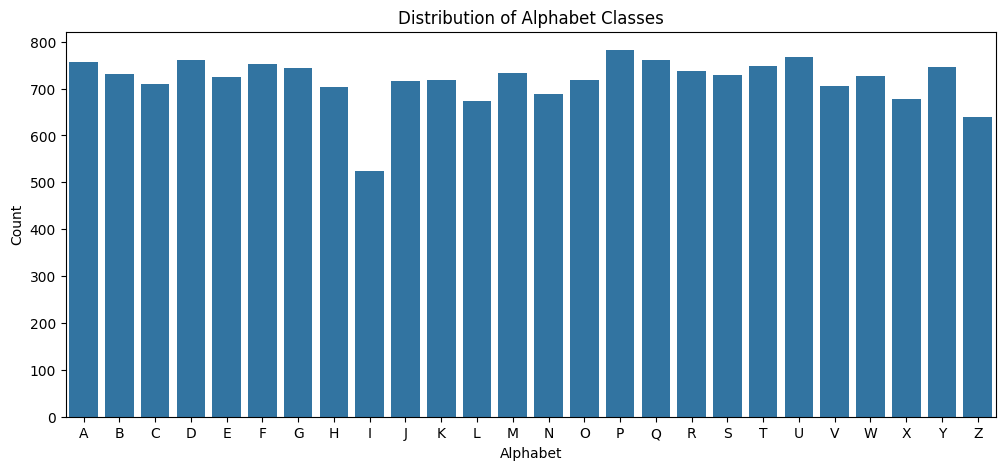

In [9]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="letter", order=sorted(df["letter"].unique()))
plt.title("Distribution of Alphabet Classes")
plt.xlabel("Alphabet")
plt.ylabel("Count")
plt.show()

### 7.2 Feature Distribution

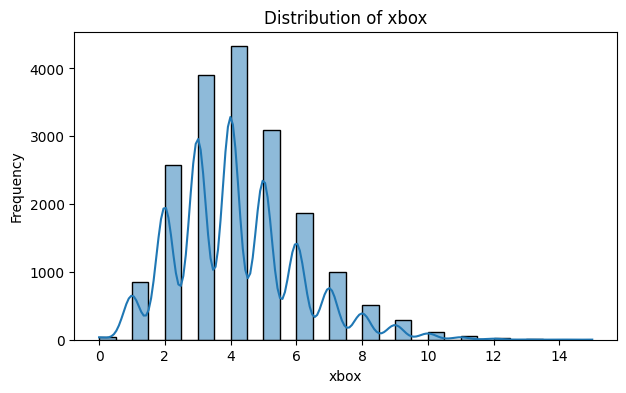

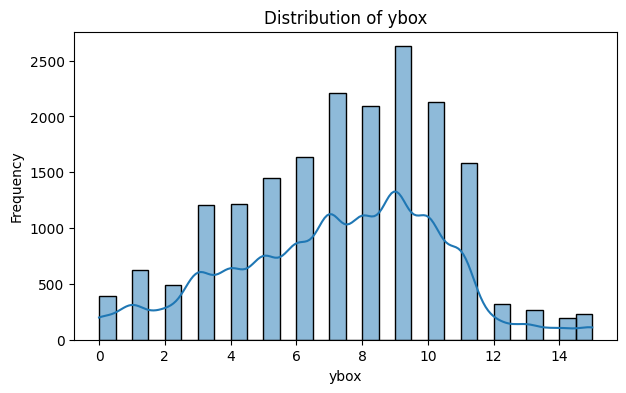

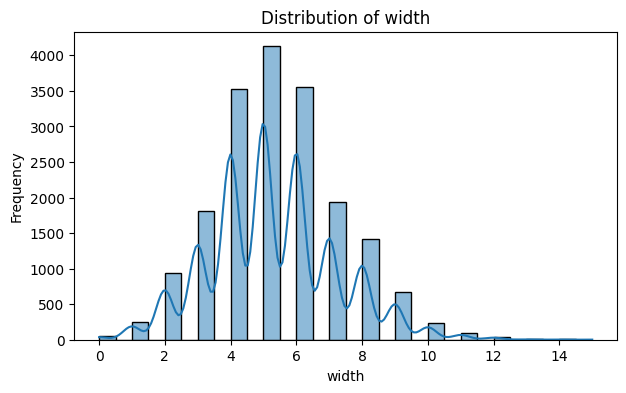

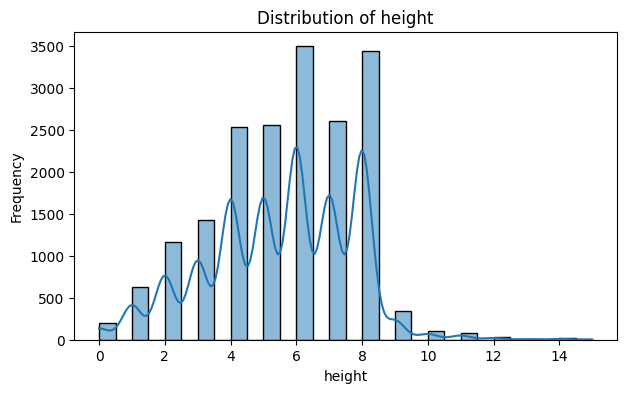

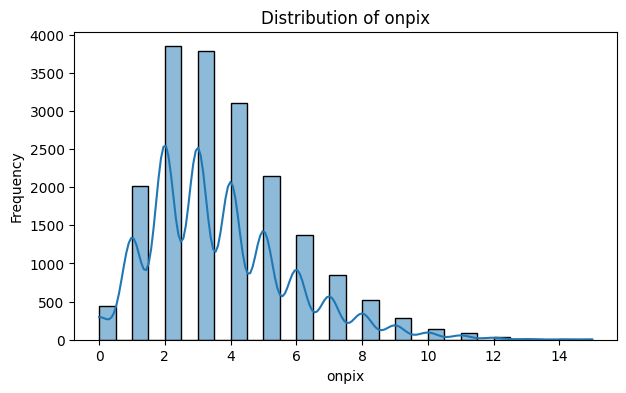

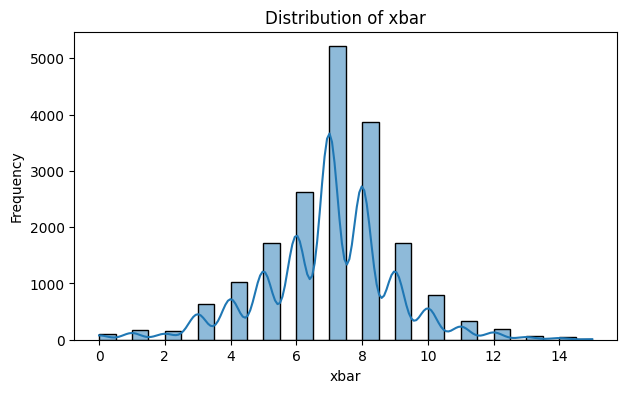

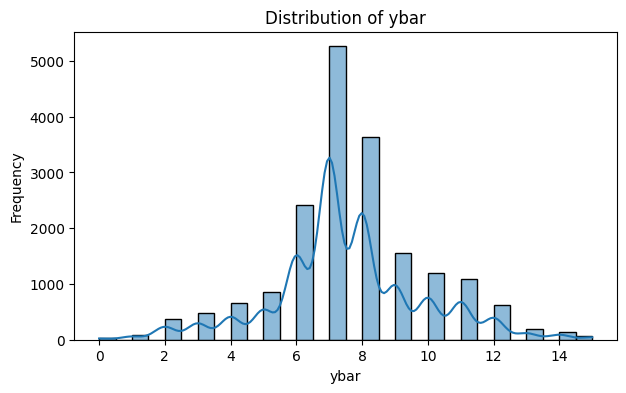

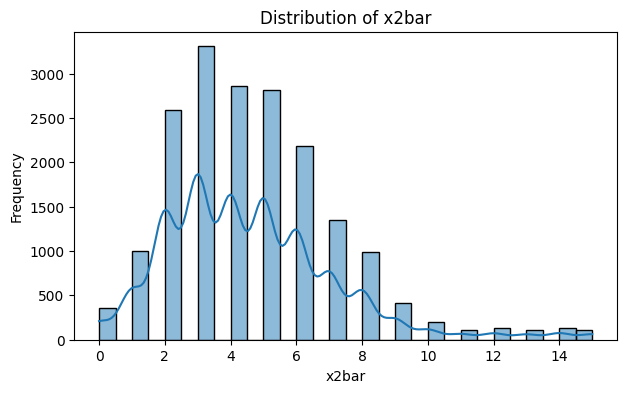

In [10]:
feature_columns = df.drop(columns=["letter"]).columns.tolist()

for col in feature_columns[:8]:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 7.3 Boxplots for Outlier Detection

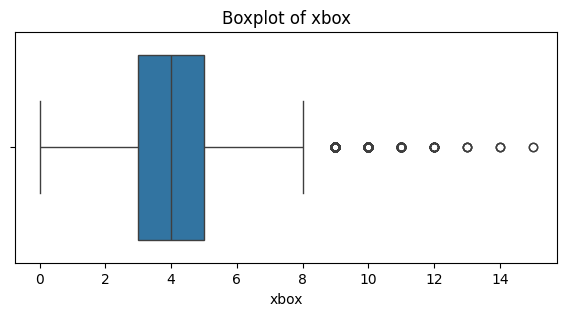

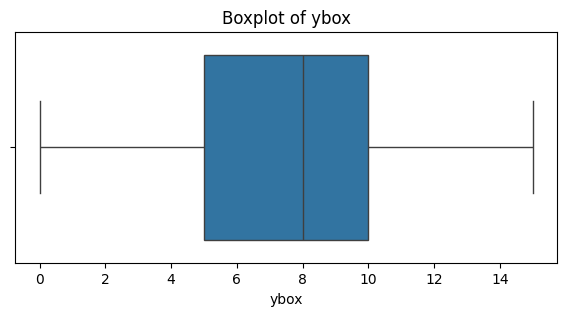

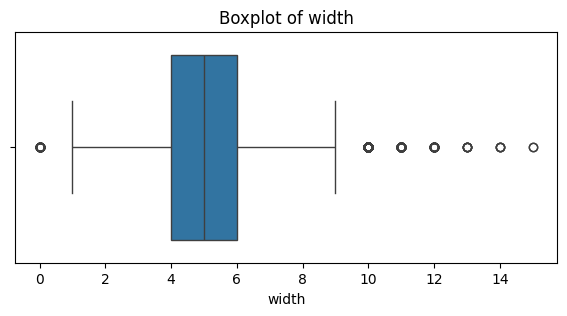

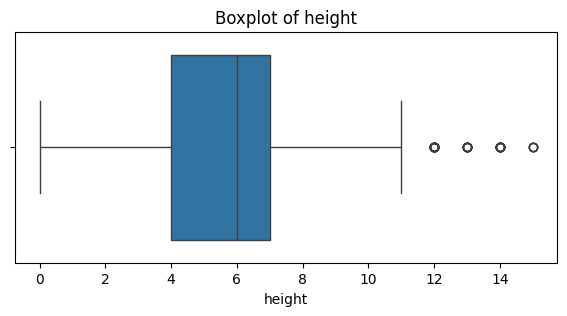

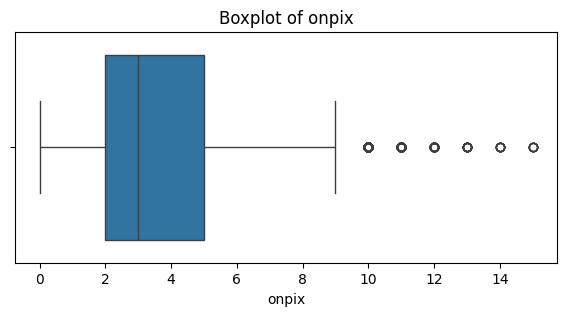

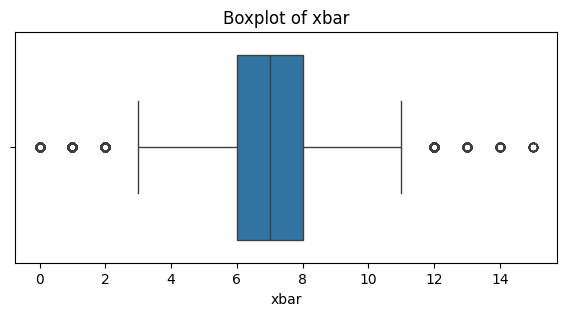

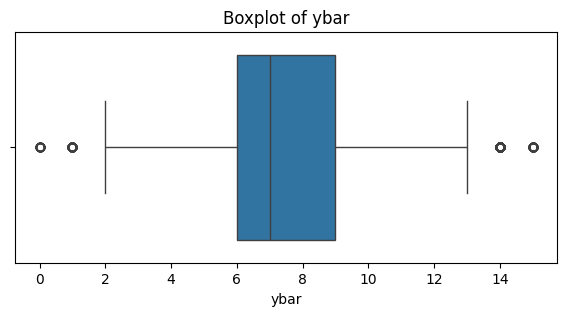

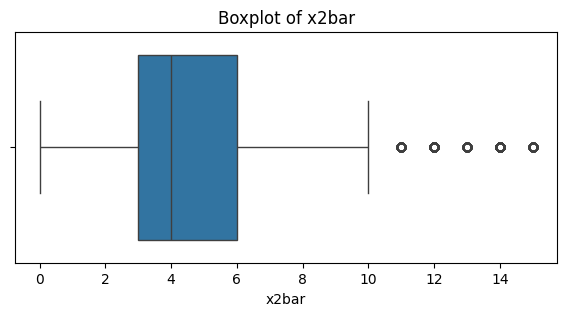

In [11]:
for col in feature_columns[:8]:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### 7.4 Correlation Heatmap

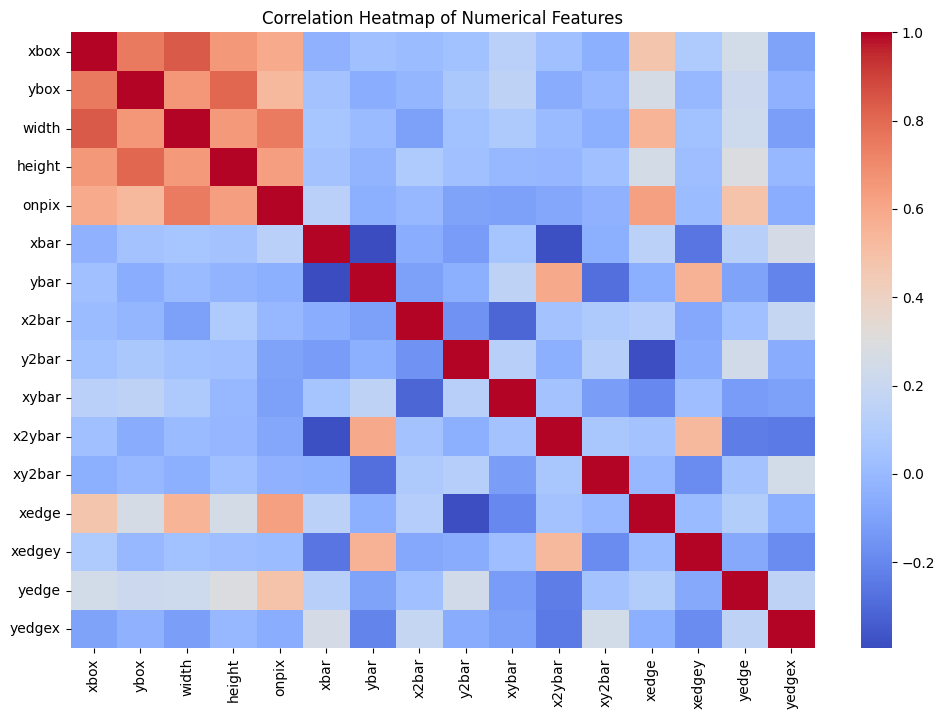

In [12]:
plt.figure(figsize=(12,8))
corr_matrix = df.drop(columns=["letter"]).corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## 8. Data Preprocessing

Steps performed:

1. Separate input features and target variable.
2. Encode alphabet labels using LabelEncoder.
3. Convert labels into categorical format for neural network output.
4. Normalize numerical features using StandardScaler.

In [13]:
X = df.drop(columns=["letter"])
y = df["letter"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# Encode target labels A-Z into numbers 0-25
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels sample:", y_encoded[:10])

# Convert target to categorical format
y_categorical = to_categorical(y_encoded)

print("Categorical target shape:", y_categorical.shape)

Feature Shape: (18668, 16)
Target Shape: (18668,)
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Encoded labels sample: [19  8  3 13  6 18  1  0  9 12]
Categorical target shape: (18668, 26)


## 9. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14934, 16)
X_test shape: (3734, 16)
y_train shape: (14934, 26)
y_test shape: (3734, 26)


## 10. Feature Scaling / Normalization

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


## 11. Basic ANN Model

The basic ANN model contains:

- Input layer
- One hidden layer
- Output layer with 26 neurons because there are 26 alphabet classes
- Softmax activation for multiclass classification

In [16]:
num_features = X_train_scaled.shape[1]
num_classes = y_train.shape[1]

basic_model = Sequential([
    Dense(64, activation="relu", input_shape=(num_features,)),
    Dense(num_classes, activation="softmax")
])

basic_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

basic_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1088      
                                                                 
 dense_1 (Dense)             (None, 26)                1690      
                                                                 
Total params: 2,778
Trainable params: 2,778
Non-trainable params: 0
_________________________________________________________________


## 12. Train Basic ANN Model

In [17]:
basic_history = basic_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
374/374 [==============================] - 2s 3ms/step - loss: 2.2321 - accuracy: 0.4234 - val_loss: 1.4974 - val_accuracy: 0.6351
Epoch 2/30
374/374 [==============================] - 1s 2ms/step - loss: 1.2222 - accuracy: 0.6838 - val_loss: 1.0805 - val_accuracy: 0.7158
Epoch 3/30
374/374 [==============================] - 1s 2ms/step - loss: 0.9460 - accuracy: 0.7433 - val_loss: 0.9175 - val_accuracy: 0.7472
Epoch 4/30
374/374 [==============================] - 1s 2ms/step - loss: 0.8098 - accuracy: 0.7744 - val_loss: 0.8158 - val_accuracy: 0.7750
Epoch 5/30
374/374 [==============================] - 1s 2ms/step - loss: 0.7189 - accuracy: 0.7965 - val_loss: 0.7401 - val_accuracy: 0.7934
Epoch 6/30
374/374 [==============================] - 1s 2ms/step - loss: 0.6518 - accuracy: 0.8159 - val_loss: 0.6782 - val_accuracy: 0.8048
Epoch 7/30
374/374 [==============================] - 1s 2ms/step - loss: 0.5976 - accuracy: 0.8304 - val_loss: 0.6351 - val_accuracy: 0.8182
Epoch 

## 13. Basic Model Training Curves

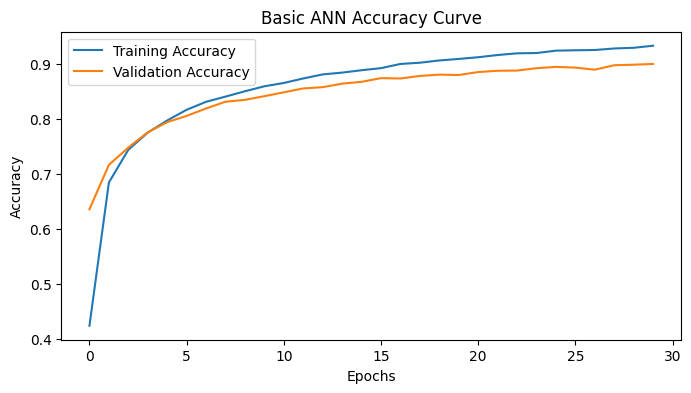

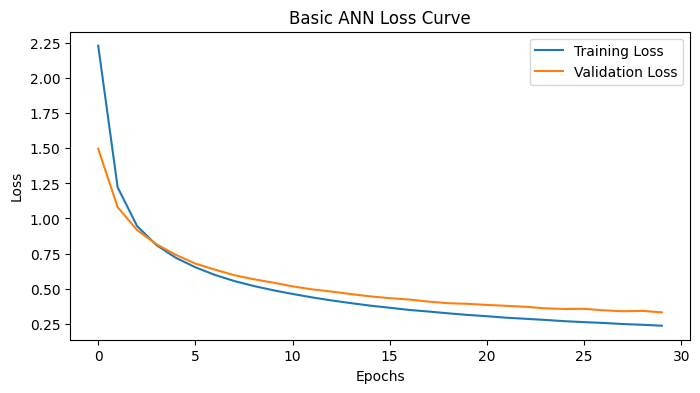

In [18]:
plt.figure(figsize=(8,4))
plt.plot(basic_history.history["accuracy"], label="Training Accuracy")
plt.plot(basic_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Basic ANN Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(basic_history.history["loss"], label="Training Loss")
plt.plot(basic_history.history["val_loss"], label="Validation Loss")
plt.title("Basic ANN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 14. Evaluate Basic ANN Model

In [19]:
basic_pred_prob = basic_model.predict(X_test_scaled)
basic_pred = np.argmax(basic_pred_prob, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

basic_accuracy = accuracy_score(y_test_labels, basic_pred)
basic_precision = precision_score(y_test_labels, basic_pred, average="weighted")
basic_recall = recall_score(y_test_labels, basic_pred, average="weighted")
basic_f1 = f1_score(y_test_labels, basic_pred, average="weighted")

print("Basic ANN Evaluation")
print("--------------------")
print("Accuracy :", round(basic_accuracy, 4))
print("Precision:", round(basic_precision, 4))
print("Recall   :", round(basic_recall, 4))
print("F1 Score :", round(basic_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test_labels, basic_pred, target_names=label_encoder.classes_))

117/117 [==============================] - 0s 932us/step
Basic ANN Evaluation
--------------------
Accuracy : 0.906
Precision: 0.9073
Recall   : 0.906
F1 Score : 0.9061

Classification Report:
              precision    recall  f1-score   support

           A       0.94      0.95      0.94       151
           B       0.83      0.92      0.87       146
           C       0.92      0.94      0.93       142
           D       0.91      0.87      0.89       152
           E       0.85      0.88      0.86       145
           F       0.91      0.88      0.89       150
           G       0.84      0.86      0.85       149
           H       0.82      0.84      0.83       141
           I       0.97      0.85      0.90       105
           J       0.94      0.93      0.94       143
           K       0.90      0.91      0.90       144
           L       0.92      0.87      0.90       134
           M       0.91      0.94      0.93       146
           N       0.88      0.89      0.89       

## 15. Confusion Matrix for Basic ANN

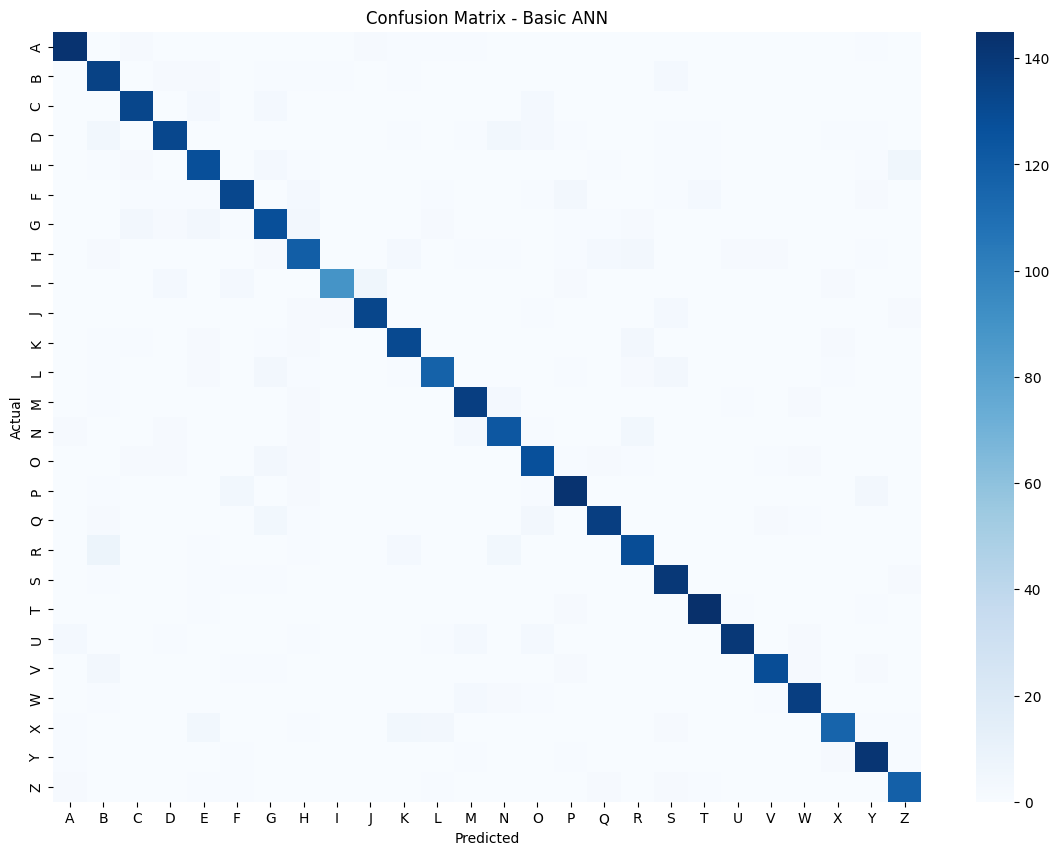

In [20]:
plt.figure(figsize=(14,10))
sns.heatmap(
    confusion_matrix(y_test_labels, basic_pred),
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Basic ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 16. Hyperparameter Tuning

We will manually test different ANN architectures using a structured loop.

Hyperparameters tested:

1. Number of hidden layers  
2. Number of neurons  
3. Activation function  
4. Learning rate  
5. Batch size  

This is a simple grid-search style approach.

In [21]:
def build_ann_model(hidden_layers=1, neurons=64, activation="relu", learning_rate=0.001, dropout_rate=0.0):
    model = Sequential()

    # First hidden layer
    model.add(Dense(neurons, activation=activation, input_shape=(num_features,)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 17. Run Hyperparameter Tuning

In [22]:
# To keep training time reasonable, we use limited combinations.
# You can increase epochs or add more combinations if needed.

param_combinations = [
    {"hidden_layers": 1, "neurons": 64, "activation": "relu", "learning_rate": 0.001, "batch_size": 32, "dropout_rate": 0.0},
    {"hidden_layers": 2, "neurons": 64, "activation": "relu", "learning_rate": 0.001, "batch_size": 32, "dropout_rate": 0.2},
    {"hidden_layers": 2, "neurons": 128, "activation": "relu", "learning_rate": 0.001, "batch_size": 32, "dropout_rate": 0.2},
    {"hidden_layers": 2, "neurons": 128, "activation": "tanh", "learning_rate": 0.001, "batch_size": 64, "dropout_rate": 0.2},
    {"hidden_layers": 3, "neurons": 128, "activation": "relu", "learning_rate": 0.0005, "batch_size": 32, "dropout_rate": 0.3}
]

tuning_results = []

for params in param_combinations:
    print("\nTraining model with parameters:", params)

    model = build_ann_model(
        hidden_layers=params["hidden_layers"],
        neurons=params["neurons"],
        activation=params["activation"],
        learning_rate=params["learning_rate"],
        dropout_rate=params["dropout_rate"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.20,
        epochs=20,
        batch_size=params["batch_size"],
        verbose=0
    )

    val_accuracy = max(history.history["val_accuracy"])

    tuning_results.append({
        "hidden_layers": params["hidden_layers"],
        "neurons": params["neurons"],
        "activation": params["activation"],
        "learning_rate": params["learning_rate"],
        "batch_size": params["batch_size"],
        "dropout_rate": params["dropout_rate"],
        "best_validation_accuracy": val_accuracy
    })

    print("Best Validation Accuracy:", round(val_accuracy, 4))

tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df.sort_values(by="best_validation_accuracy", ascending=False))


Training model with parameters: {'hidden_layers': 1, 'neurons': 64, 'activation': 'relu', 'learning_rate': 0.001, 'batch_size': 32, 'dropout_rate': 0.0}
Best Validation Accuracy: 0.8808

Training model with parameters: {'hidden_layers': 2, 'neurons': 64, 'activation': 'relu', 'learning_rate': 0.001, 'batch_size': 32, 'dropout_rate': 0.2}
Best Validation Accuracy: 0.8845

Training model with parameters: {'hidden_layers': 2, 'neurons': 128, 'activation': 'relu', 'learning_rate': 0.001, 'batch_size': 32, 'dropout_rate': 0.2}
Best Validation Accuracy: 0.9347

Training model with parameters: {'hidden_layers': 2, 'neurons': 128, 'activation': 'tanh', 'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.2}
Best Validation Accuracy: 0.8972

Training model with parameters: {'hidden_layers': 3, 'neurons': 128, 'activation': 'relu', 'learning_rate': 0.0005, 'batch_size': 32, 'dropout_rate': 0.3}
Best Validation Accuracy: 0.8895


,hidden_layers,neurons,activation,learning_rate,batch_size,dropout_rate,best_validation_accuracy
2,2,128,relu,0.0010,32,0.2,0.934717
3,2,128,tanh,0.0010,64,0.2,0.897221
4,3,128,relu,0.0005,32,0.3,0.889521
1,2,64,relu,0.0010,32,0.2,0.884499
0,1,64,relu,0.0010,32,0.0,0.880817


## 18. Select Best Hyperparameters

In [23]:
best_params = tuning_results_df.sort_values(by="best_validation_accuracy", ascending=False).iloc[0].to_dict()

print("Best Hyperparameters:")
print(best_params)

Best Hyperparameters:
{'hidden_layers': 2, 'neurons': 128, 'activation': 'relu', 'learning_rate': 0.001, 'batch_size': 32, 'dropout_rate': 0.2, 'best_validation_accuracy': 0.9347171187400818}


## 19. Build Tuned ANN Model

In [24]:
tuned_model = build_ann_model(
    hidden_layers=int(best_params["hidden_layers"]),
    neurons=int(best_params["neurons"]),
    activation=best_params["activation"],
    learning_rate=float(best_params["learning_rate"]),
    dropout_rate=float(best_params["dropout_rate"])
)

tuned_model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_17 (Dense)            (None, 128)               2176      
                                                                 
 dropout_9 (Dropout)         (None, 128)               0         
                                                                 
 dense_18 (Dense)            (None, 128)               16512     
                                                                 
 dropout_10 (Dropout)        (None, 128)               0         
                                                                 
 dense_19 (Dense)            (None, 26)                3354      
                                                                 
Total params: 22,042
Trainable params: 22,042
Non-trainable params: 0
_________________________________________________________________


## 20. Train Tuned ANN Model

In [25]:
tuned_history = tuned_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=40,
    batch_size=int(best_params["batch_size"]),
    verbose=1
)

Epoch 1/40
374/374 [==============================] - 2s 4ms/step - loss: 1.7269 - accuracy: 0.5001 - val_loss: 0.9792 - val_accuracy: 0.7258
Epoch 2/40
374/374 [==============================] - 1s 3ms/step - loss: 0.9712 - accuracy: 0.6967 - val_loss: 0.7547 - val_accuracy: 0.7790
Epoch 3/40
374/374 [==============================] - 1s 3ms/step - loss: 0.7832 - accuracy: 0.7580 - val_loss: 0.6156 - val_accuracy: 0.8129
Epoch 4/40
374/374 [==============================] - 1s 3ms/step - loss: 0.6781 - accuracy: 0.7837 - val_loss: 0.5323 - val_accuracy: 0.8460
Epoch 5/40
374/374 [==============================] - 1s 3ms/step - loss: 0.5941 - accuracy: 0.8116 - val_loss: 0.4642 - val_accuracy: 0.8651
Epoch 6/40
374/374 [==============================] - 1s 3ms/step - loss: 0.5463 - accuracy: 0.8272 - val_loss: 0.4237 - val_accuracy: 0.8738
Epoch 7/40
374/374 [==============================] - 1s 3ms/step - loss: 0.4995 - accuracy: 0.8406 - val_loss: 0.3852 - val_accuracy: 0.8865
Epoch 

## 21. Tuned Model Training Curves

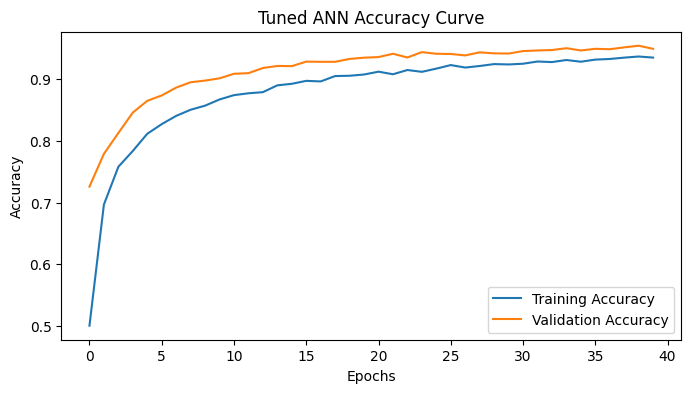

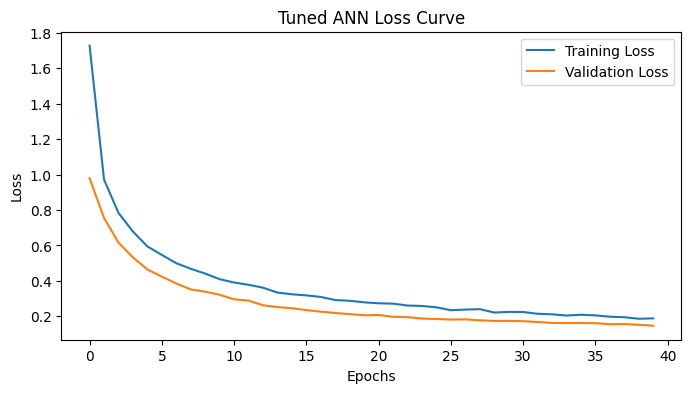

In [26]:
plt.figure(figsize=(8,4))
plt.plot(tuned_history.history["accuracy"], label="Training Accuracy")
plt.plot(tuned_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Tuned ANN Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(tuned_history.history["loss"], label="Training Loss")
plt.plot(tuned_history.history["val_loss"], label="Validation Loss")
plt.title("Tuned ANN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 22. Evaluate Tuned ANN Model

In [27]:
tuned_pred_prob = tuned_model.predict(X_test_scaled)
tuned_pred = np.argmax(tuned_pred_prob, axis=1)

tuned_accuracy = accuracy_score(y_test_labels, tuned_pred)
tuned_precision = precision_score(y_test_labels, tuned_pred, average="weighted")
tuned_recall = recall_score(y_test_labels, tuned_pred, average="weighted")
tuned_f1 = f1_score(y_test_labels, tuned_pred, average="weighted")

print("Tuned ANN Evaluation")
print("--------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test_labels, tuned_pred, target_names=label_encoder.classes_))

117/117 [==============================] - 0s 811us/step
Tuned ANN Evaluation
--------------------
Accuracy : 0.9531
Precision: 0.9537
Recall   : 0.9531
F1 Score : 0.9532

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.97      0.98       151
           B       0.91      0.95      0.93       146
           C       0.94      0.96      0.95       142
           D       0.94      0.95      0.95       152
           E       0.94      0.92      0.93       145
           F       0.90      0.93      0.91       150
           G       0.90      0.92      0.91       149
           H       0.95      0.91      0.93       141
           I       0.97      0.90      0.93       105
           J       0.93      0.97      0.95       143
           K       0.95      0.98      0.96       144
           L       0.98      0.93      0.95       134
           M       0.99      0.99      0.99       146
           N       0.96      0.95      0.96     

## 23. Confusion Matrix for Tuned ANN

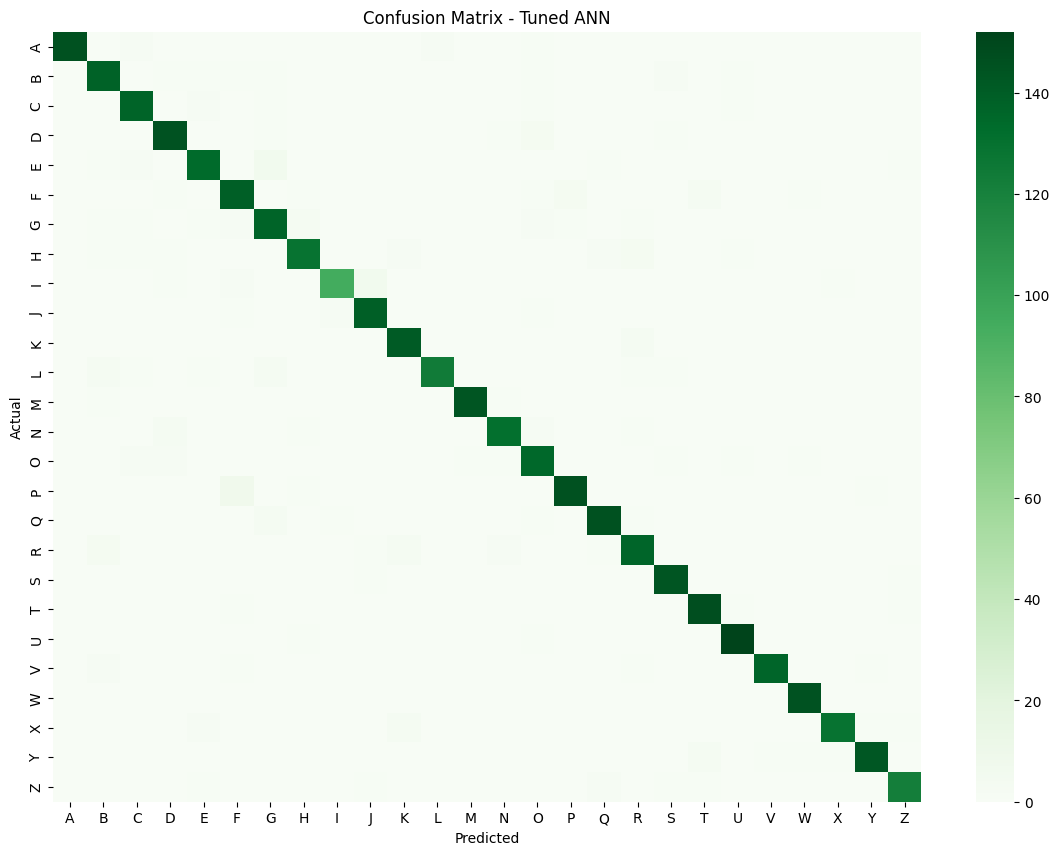

In [28]:
plt.figure(figsize=(14,10))
sns.heatmap(
    confusion_matrix(y_test_labels, tuned_pred),
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Tuned ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 24. Compare Basic and Tuned ANN Models

,Model,Accuracy,Precision,Recall,F1 Score
0,Basic ANN,0.905999,0.907300,0.905999,0.906122
1,Tuned ANN,0.953133,0.953717,0.953133,0.953191


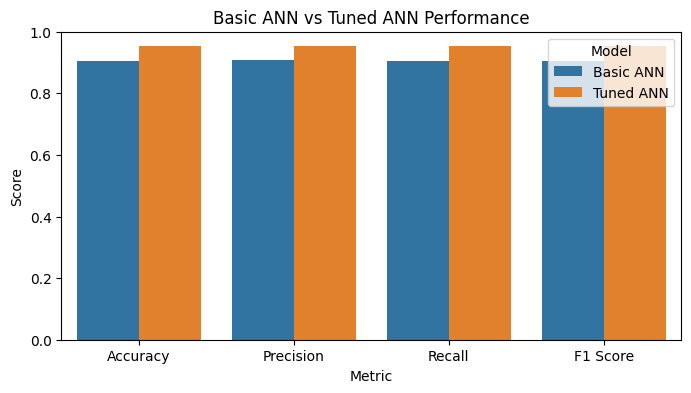

In [29]:
comparison_df = pd.DataFrame({
    "Model": ["Basic ANN", "Tuned ANN"],
    "Accuracy": [basic_accuracy, tuned_accuracy],
    "Precision": [basic_precision, tuned_precision],
    "Recall": [basic_recall, tuned_recall],
    "F1 Score": [basic_f1, tuned_f1]
})

display(comparison_df)

plt.figure(figsize=(8,4))
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model")
plt.title("Basic ANN vs Tuned ANN Performance")
plt.ylim(0, 1)
plt.show()

## 25. Discussion on Hyperparameter Tuning

Hyperparameter tuning helps improve ANN performance by finding a better combination of model settings.

Important hyperparameters:

1. **Hidden layers**  
   More hidden layers allow the model to learn complex patterns.

2. **Neurons per layer**  
   More neurons can increase learning capacity, but too many may cause overfitting.

3. **Activation function**  
   ReLU is commonly used because it trains faster and handles non-linearity well.

4. **Learning rate**  
   A high learning rate may miss the best solution, while a very low learning rate trains slowly.

5. **Batch size**  
   Batch size controls how many samples are used before updating weights.

6. **Dropout**  
   Dropout helps reduce overfitting by randomly ignoring some neurons during training.

## 26. Final Conclusion

In this assignment, an Artificial Neural Network was developed to classify alphabet letters using the `Alphabets_data.csv` dataset. The dataset was explored, cleaned, normalized, and prepared for classification.

A basic ANN model was first trained using one hidden layer. After that, hyperparameter tuning was performed by testing different hidden layers, neurons, activation functions, learning rates, batch sizes, and dropout rates.

The tuned ANN model was evaluated using accuracy, precision, recall, and F1-score. The performance of the tuned model was compared with the basic model. Hyperparameter tuning helped identify a better model configuration and improved the classification performance.

This assignment demonstrates how ANN models can be used for multiclass classification problems and how tuning can improve model accuracy and generalization.